# EDA PARA DATASET VIGILANCIA MALARIA EN PERÚ (2009 - 2024)
## OBJETIVO: Predecir picos epidemiológicos por semana para prevención
### NOMBRE: CALED ITAMAR LIMA ROQUE

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
%run '/content/pandas_missing_extension.ipynb'

In [ ]:
PATH_CSV = '/content/drive/MyDrive/CODIGO_G6/Proyecto_final_malaria_peru/vigilancia_malaria_2009_2024.csv'
df = pd.read_csv(PATH_CSV)
df.head()

/tmp/ipykernel_2874/1979242536.py:2: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(PATH_CSV)


,departamento,provincia,distrito,localidad,enfermedad,ano,semana,diagnostic,diresa,ubigeo,localcod,edad,tipo_edad,sexo
0,TUMBES,ZARUMILLA,AGUAS VERDES,AGUAS VERDES,MALARIA POR P. VIVAX,2009,15,B51,24,240302,2403020001,32,A,M
1,ANCASH,CASMA,BUENA VISTA ALTA,HUANCHUY,MALARIA POR P. VIVAX,2009,18,B51,2,20802,0208020002,7,A,M
2,MADRE DE DIOS,MANU,MADRE DE DIOS,BOCA PUKIRI,MALARIA POR P. VIVAX,2009,19,B51,17,170203,1702030010,17,A,M
3,PIURA,SULLANA,SULLANA,HUANGALA,MALARIA POR P. VIVAX,2009,21,B51,31,200601,2006010023,53,A,F
4,ANCASH,YUNGAY,RANRAHIRCA,CAJAPAMPA,MALARIA POR P. VIVAX,2009,22,B51,2,22006,0220060006,24,A,M


In [ ]:
df.tail()

,departamento,provincia,distrito,localidad,enfermedad,ano,semana,diagnostic,diresa,ubigeo,localcod,edad,tipo_edad,sexo
597136,LORETO,MAYNAS,IQUITOS,IQUITOS,MALARIA POR P. VIVAX,2024,28,B51,16,160101,1601010001,64,A,F
597137,LORETO,LORETO,URARINAS,SANTA ROSA DE FIRMEZA,MALARIA POR P. VIVAX,2024,34,B51,16,160305,1603051011,32,A,M
597138,LORETO,LORETO,URARINAS,SANTA ROSA DE FIRMEZA,MALARIA P. FALCIPARUM,2024,48,B50,16,160305,1603051011,14,A,F
597139,LORETO,MAYNAS,IQUITOS,NaN,MALARIA POR P. VIVAX,2024,26,B51,16,160101,NaN,24,A,M
597140,LORETO,MARISCAL RAMON CASTILLA,SAN PABLO,9 DE OCTUBRE,MALARIA P. FALCIPARUM,2024,17,B50,16,160404,1604040040,17,A,M


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 597141 entries, 0 to 597140
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   departamento  597141 non-null  object
 1   provincia     597141 non-null  object
 2   distrito      597141 non-null  object
 3   localidad     578548 non-null  object
 4   enfermedad    597141 non-null  object
 5   ano           597141 non-null  int64 
 6   semana        597141 non-null  int64 
 7   diagnostic    597141 non-null  object
 8   diresa        597141 non-null  int64 
 9   ubigeo        597141 non-null  int64 
 10  localcod      591639 non-null  object
 11  edad          597141 non-null  int64 
 12  tipo_edad     597141 non-null  object
 13  sexo          597141 non-null  object
dtypes: int64(5), object(9)
memory usage: 63.8+ MB


# RESUMEN ESTADÍSTICO

In [ ]:
df.describe(include='all')

,departamento,provincia,distrito,localidad,enfermedad,ano,semana,diagnostic,diresa,ubigeo,localcod,edad,tipo_edad,sexo
count,597141,597141,597141,578548,597141,597141.000000,597141.000000,597141,597141.00000,597141.000000,591639,5.971410e+05,597141,597141
unique,22,102,381,4046,2,NaN,NaN,2,NaN,NaN,8645,NaN,3,2
top,LORETO,MAYNAS,ANDOAS,NAUTA,MALARIA POR P. VIVAX,NaN,NaN,B51,NaN,NaN,1601130001,NaN,A,M
freq,517417,183680,74701,9874,490097,NaN,NaN,490097,NaN,NaN,6208,NaN,589374,331689
mean,NaN,NaN,NaN,NaN,NaN,2015.911704,26.173195,NaN,16.19946,155200.368369,NaN,2.078259e+03,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,4.115623,14.157415,NaN,3.63675,28147.546046,NaN,3.714870e+05,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,2009.000000,1.000000,NaN,2.00000,10103.000000,NaN,1.000000e+00,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,2013.000000,15.000000,NaN,16.00000,160108.000000,NaN,7.000000e+00,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,2016.000000,26.000000,NaN,16.00000,160303.000000,NaN,1.500000e+01,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,2018.000000,38.000000,NaN,16.00000,160703.000000,NaN,3.000000e+01,NaN,NaN


# TRATAMIENTO DE NULOS

In [ ]:
df.shape[0]

597141

In [ ]:
# Uso de la extensión personalizada del docente para nulos
df.missing.number_missing()

np.int64(24095)

In [ ]:
df.missing.number_complete()

np.int64(8335879)

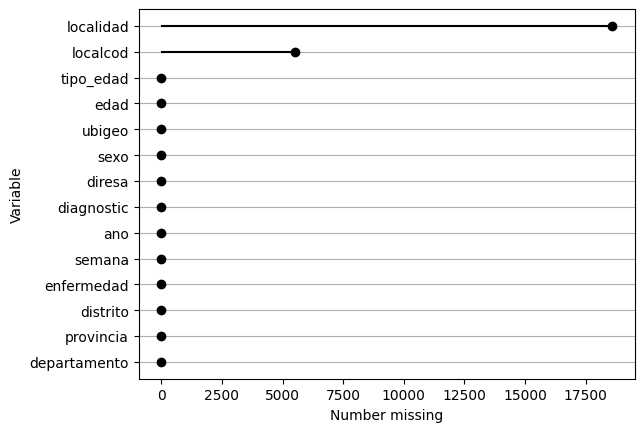

In [ ]:
df.missing.missing_variable_plot()

<Axes: >

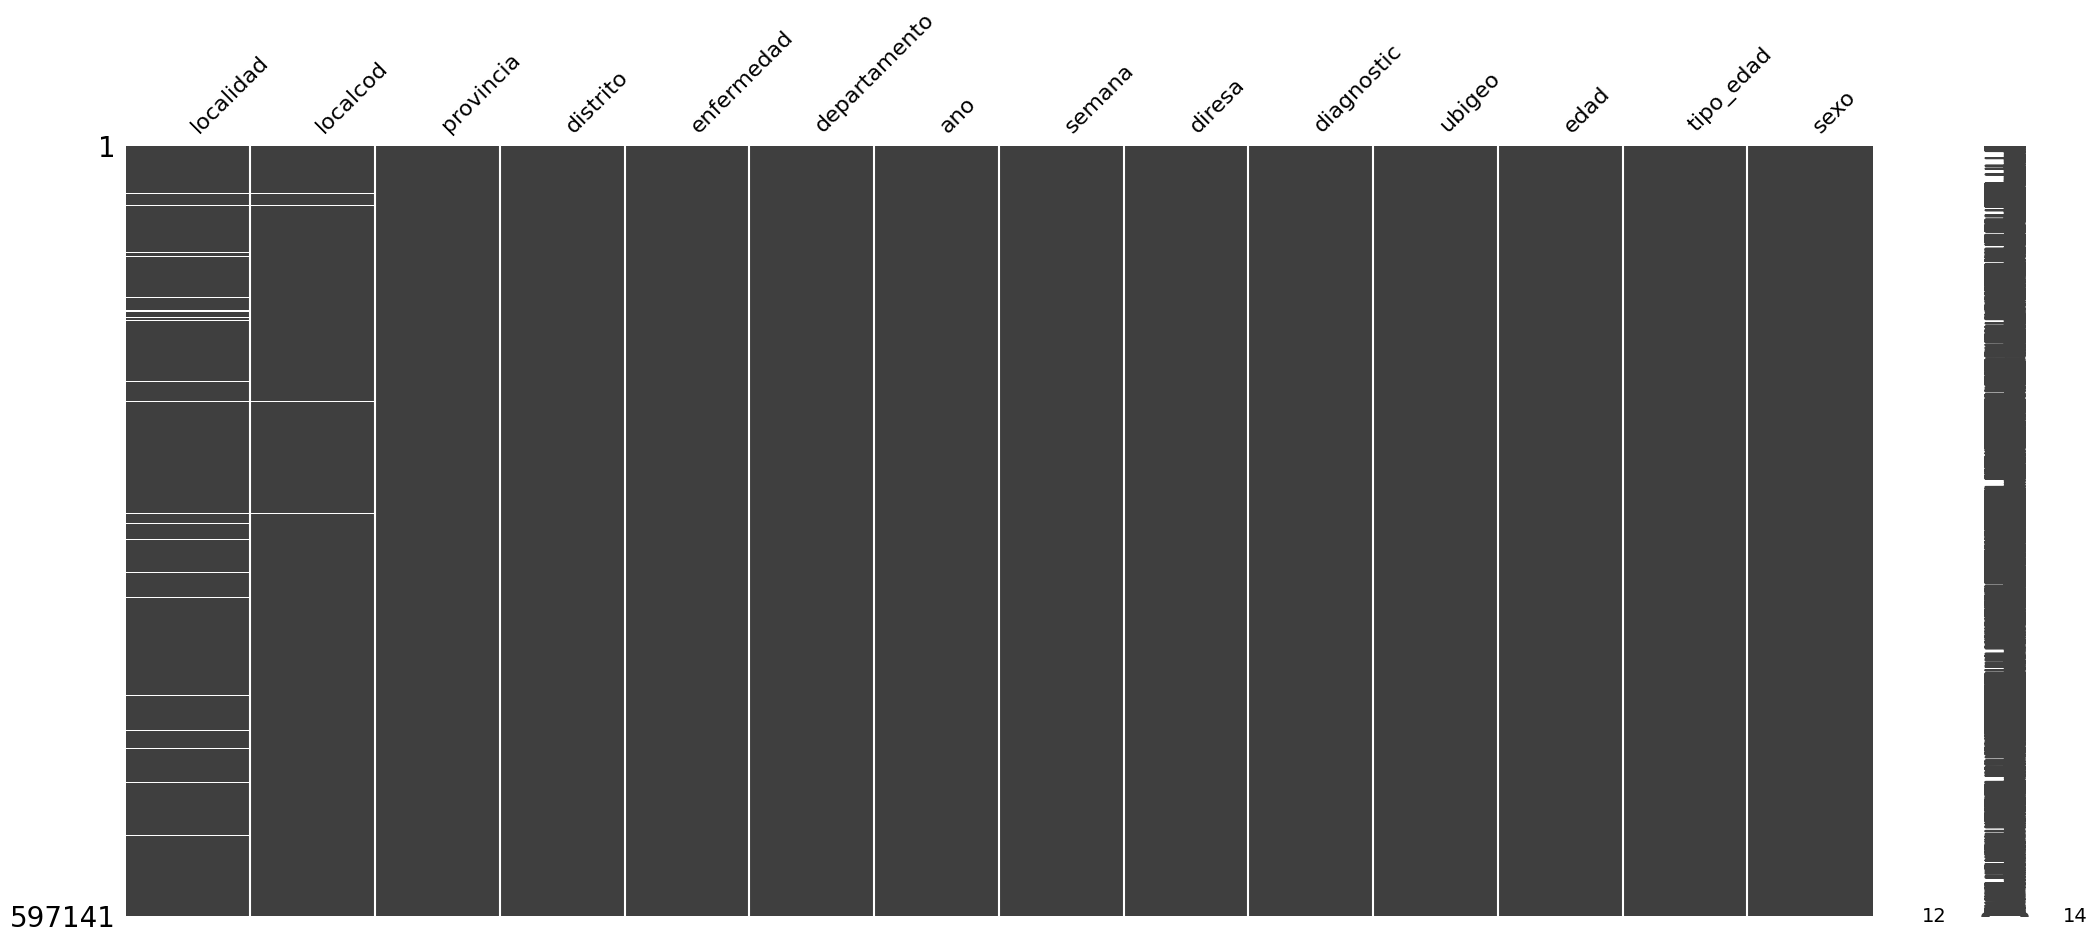

In [ ]:
import missingno

# Matriz de visualización de nulos
df.missing.sort_variables_by_missingness().pipe(missingno.matrix)

# DISTRIBUCIÓN DE CASOS POR AÑO Y SEMANA

/tmp/ipykernel_2874/1357172471.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='ano', palette='viridis')


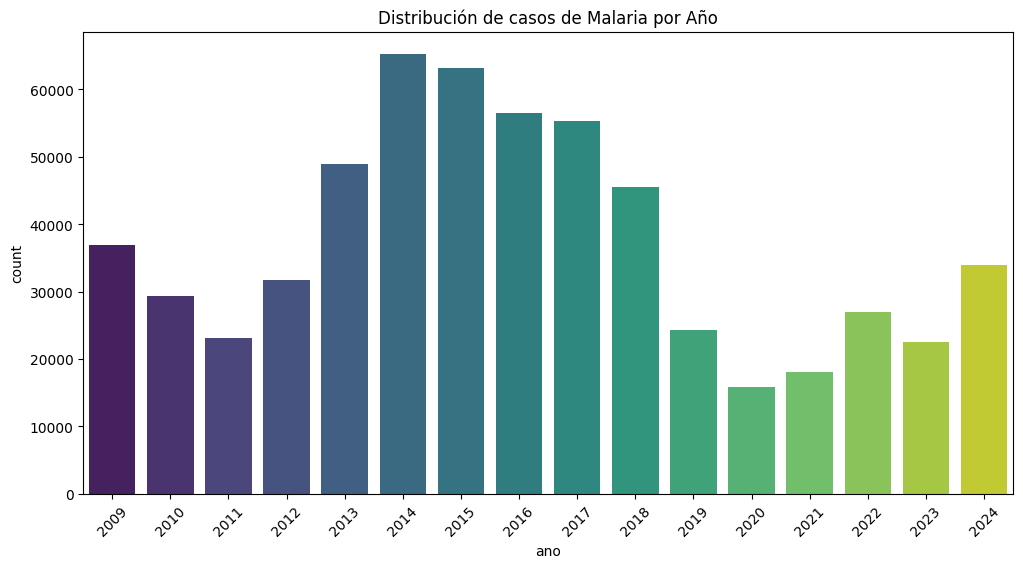

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='ano', palette='viridis')
plt.title('Distribución de casos de Malaria por Año')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_2874/4248235329.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='semana', palette='magma')


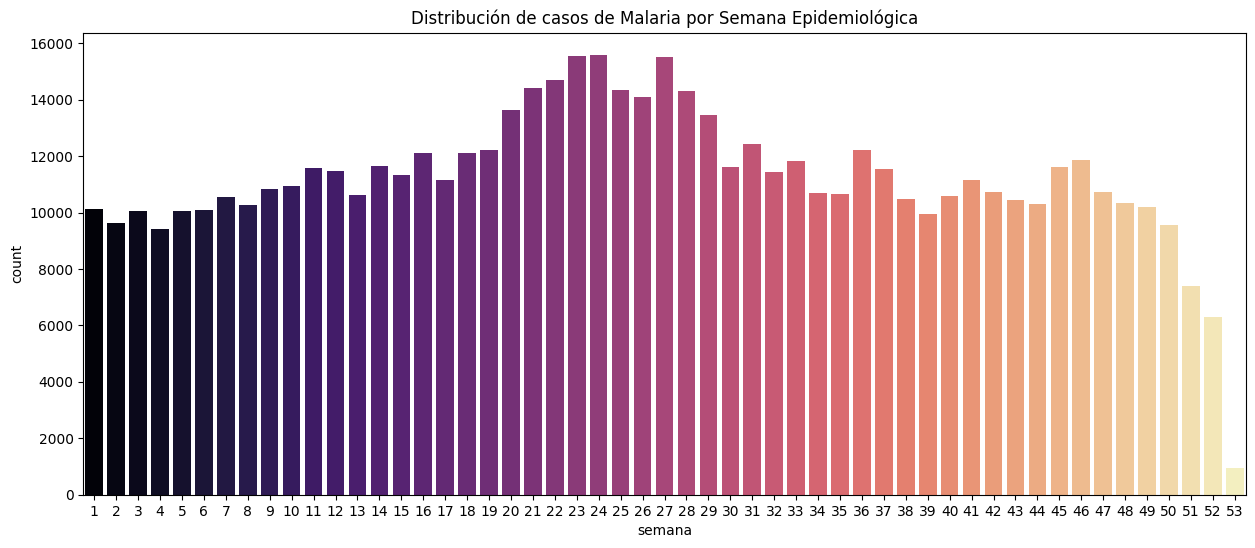

In [ ]:
plt.figure(figsize=(15, 6))
sns.countplot(data=df, x='semana', palette='magma')
plt.title('Distribución de casos de Malaria por Semana Epidemiológica')
plt.show()

# TOP DEPARTAMENTOS Y PROVINCIAS CON MÁS CASOS

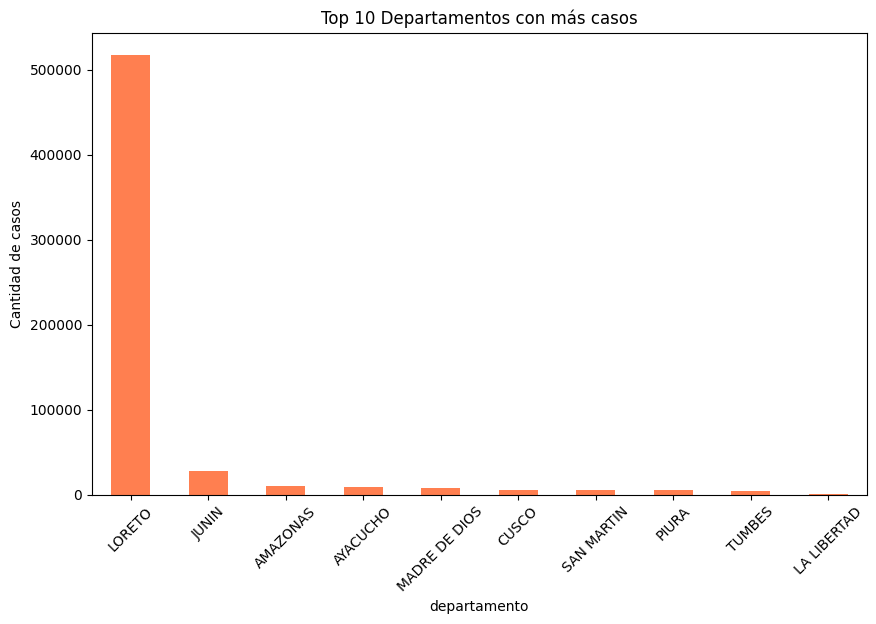

In [ ]:
plt.figure(figsize=(10, 6))
df['departamento'].value_counts().head(10).plot(kind='bar', color='coral')
plt.title('Top 10 Departamentos con más casos')
plt.ylabel('Cantidad de casos')
plt.xticks(rotation=45)
plt.show()

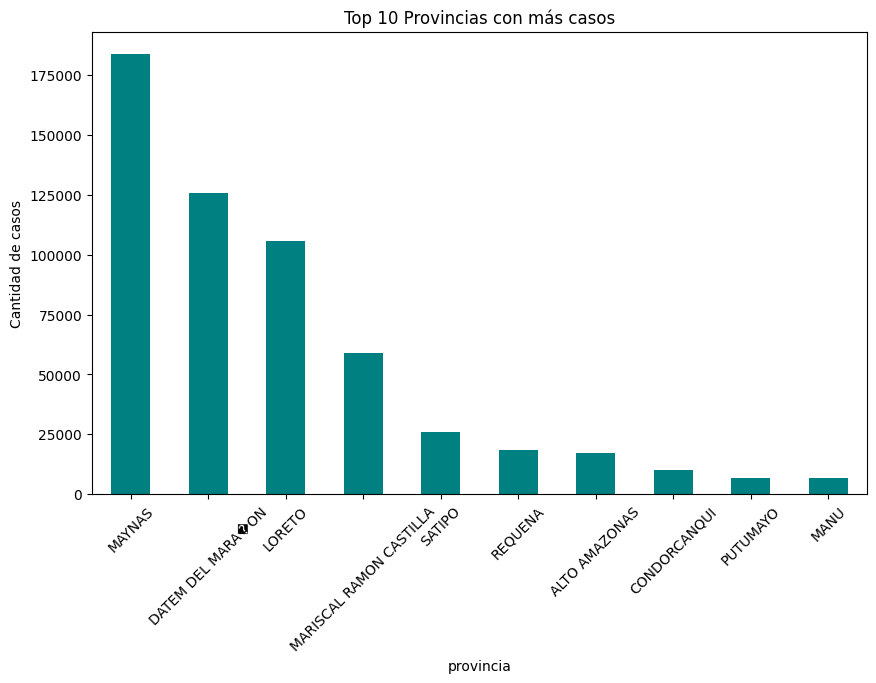

In [ ]:
plt.figure(figsize=(10, 6))
df['provincia'].value_counts().head(10).plot(kind='bar', color='teal')
plt.title('Top 10 Provincias con más casos')
plt.ylabel('Cantidad de casos')
plt.xticks(rotation=45)
plt.show()

# DISTRIBUCIÓN POR SEXO Y GRUPO ETARIO

/tmp/ipykernel_2874/829668460.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sexo', palette='Set2')


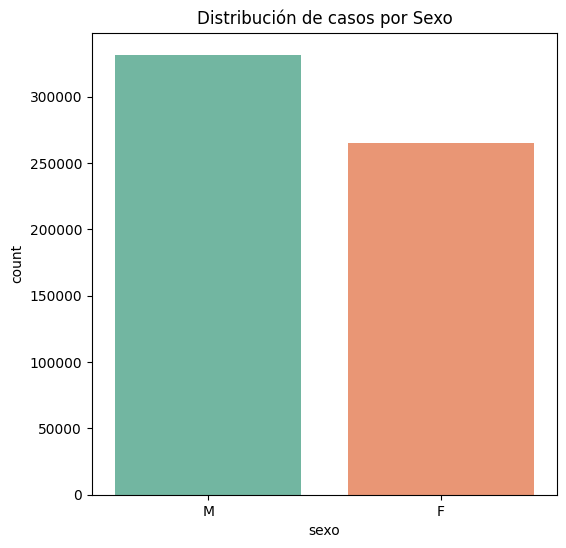

In [ ]:
plt.figure(figsize=(6, 6))
sns.countplot(data=df, x='sexo', palette='Set2')
plt.title('Distribución de casos por Sexo')
plt.show()

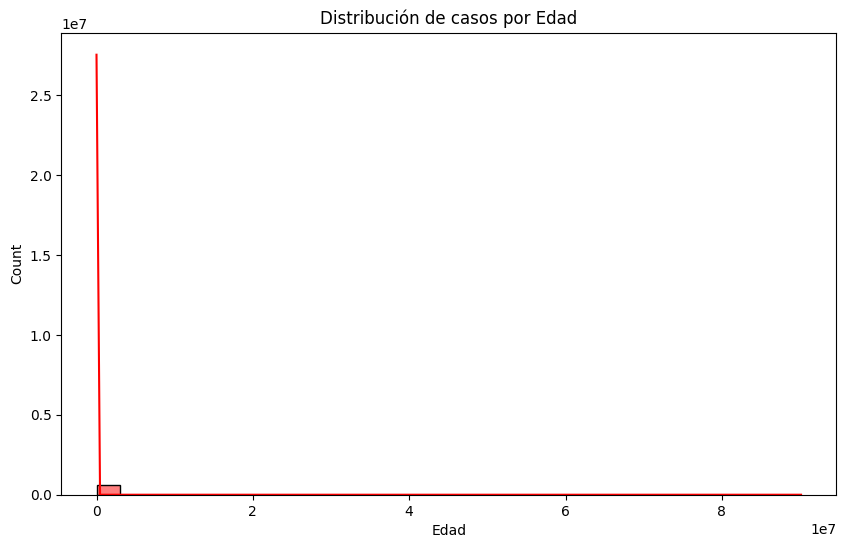

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='edad', bins=30, kde=True, color='red')
plt.title('Distribución de casos por Edad')
plt.xlabel('Edad')
plt.show()

# SERIE TEMPORAL BÁSICA DE CASOS POR SEMANA

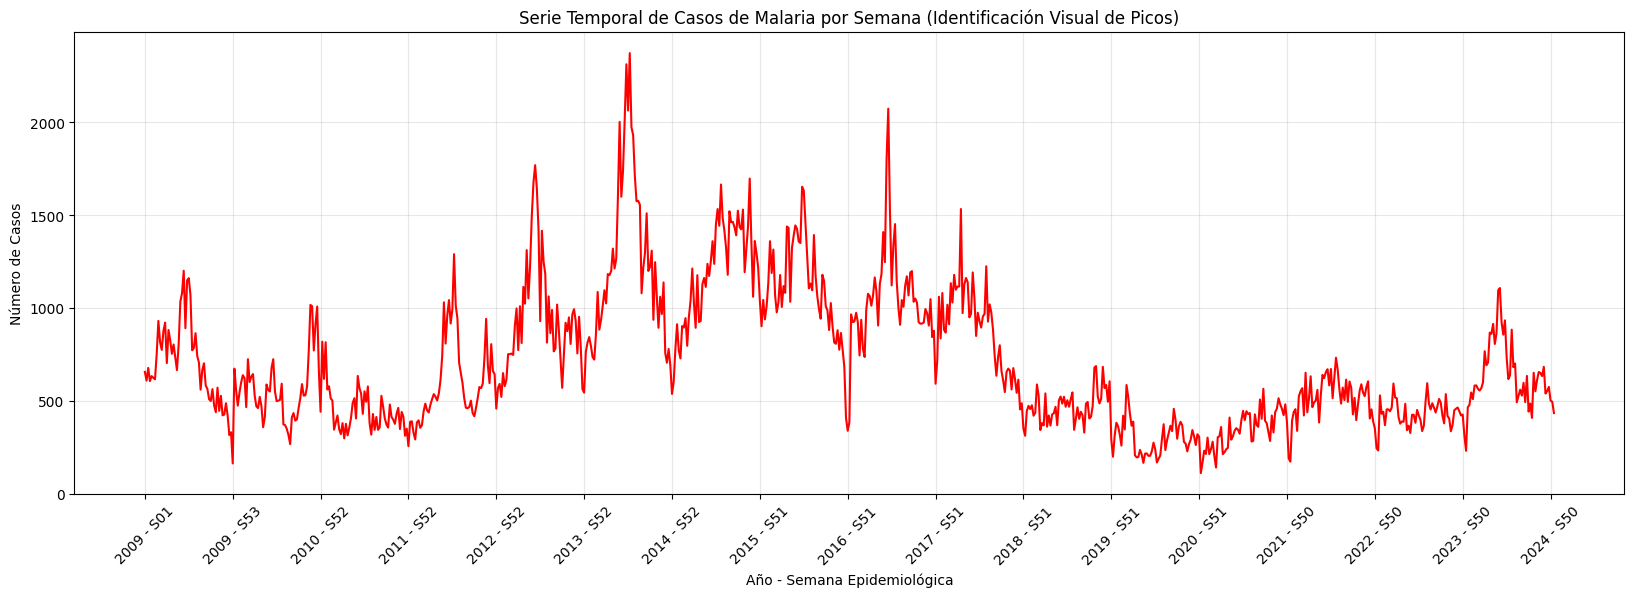

In [ ]:
# Agrupamos los datos históricamente para observar la línea de tiempo real
casos_por_semana = df.groupby(['ano', 'semana']).size().reset_index(name='casos')

# Creamos una columna combinada para el eje temporal
casos_por_semana['tiempo'] = casos_por_semana['ano'].astype(str) + " - S" + casos_por_semana['semana'].astype(str).str.zfill(2)

plt.figure(figsize=(20, 6))
sns.lineplot(data=casos_por_semana, x='tiempo', y='casos', color='red')
plt.title('Serie Temporal de Casos de Malaria por Semana (Identificación Visual de Picos)')
# Mostramos un tick cada 52 semanas (aproximadamente 1 año) para no saturar el eje X
plt.xticks(np.arange(0, len(casos_por_semana), step=52), rotation=45)
plt.xlabel('Año - Semana Epidemiológica')
plt.ylabel('Número de Casos')
plt.grid(True, alpha=0.3)
plt.show()

1. **Comportamiento Temporal y Picos:** El gráfico de serie temporal confirma la existencia de una fuerte estacionalidad. Los picos epidemiológicos ocurren en ventanas de semanas específicas cada año, lo cual valida que construir un modelo predictivo basado en la semana del año es el enfoque correcto para la prevención.
2. **Foco Geográfico:** La enfermedad no se distribuye uniformemente; departamentos específicos (históricamente en zonas selva como Loreto, pero abarcando también focos críticos locales) concentran la vasta mayoría de casos. El `departamento` y la `provincia` serán variables predictoras clave.
3. **Distribución Demográfica:** El análisis por sexo y grupo etario evidencia a los grupos poblacionales más vulnerables. Estas variables pueden usarse como características de entrada (features) para refinar la sensibilidad del modelo y emitir alertas tempranas segmentadas.
4. **Tratamiento de Datos Pendiente:** Se identificó la proporción de valores nulos (a través de la librería del entorno). Antes de aplicar algoritmos de Machine Learning, estas filas deberán ser imputadas o descartadas en la etapa de preprocesamiento.

In [ ]:
# Tratamiento de nulos: Dado el gran volumen de datos (más de 500 mil filas),
# una estrategia inicial válida para este bootcamp es eliminar las filas con valores nulos.
# (Si el docente exige imputación por media/moda, se reemplazaría el dropna por fillna).
df_clean = df.dropna()

# Verificamos la nueva cantidad de filas tras la limpieza
df_clean.shape[0]

578524

In [ ]:
# Comprobamos con la extensión que ya no queden datos faltantes
df_clean.missing.number_missing()

np.int64(0)

# EXPORTACIÓN DEL DATASET LIMPIO

In [ ]:
# Definimos la ruta de salida en la misma carpeta del proyecto
PATH_CLEAN_CSV = '/content/drive/MyDrive/CODIGO_G6/Proyecto_final_malaria_peru/vigilancia_malaria_2009_2024_cleaned.csv'

# Exportamos el dataframe limpio sin el índice
df_clean.to_csv(PATH_CLEAN_CSV, index=False)

print(f"Archivo limpio exportado exitosamente en: {PATH_CLEAN_CSV}")

Archivo limpio exportado exitosamente en: /content/drive/MyDrive/CODIGO_G6/Proyecto_final_malaria_peru/vigilancia_malaria_2009_2024_cleaned.csv
